<h1>Categorical Shift Comparison (Humans vs. LLMs)</h1>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# initializing high level instances, with config
from preprocessor import Preprocessor
from config_local import config
import pandas as pd
from visualizer import Visualizer
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

Load LLM dataset

In [3]:
# Load LLM paths dataset
llm_df = pd.read_csv("results/llm_paths_oss_20b.csv")

In [4]:
# Inspect LLM paths
llm_df.head(10)

,id,start,destination,blind_paths,blind_input_tokens,blind_output_tokens,link_aware_paths,link_aware_input_tokens,link_aware_output_tokens,external_info_paths,external_info_input_tokens,external_info_output_tokens,tot_paths,tot_input_tokens,tot_output_tokens
0,Brain_Telephone_0,Brain,Telephone,"[""Brain"", ""Cognitive science"", ""Communication""...",298,444,"[""Brain"", ""Computer_science"", ""Internet""]",3036,3312,"[""Brain"", ""Action\u00a0potential""]",1594,855,"[""Brain"", ""Computer_science"", ""Information"", ""...",9653,10084
1,Theatre_Zebra_0,Theatre,Zebra,"[""Theatre"", ""Performing arts"", ""Circus"", ""Circ...",300,1276,"[""Theatre"", ""France"", ""Kenya"", ""East_Africa"", ...",5196,2950,"[""Theatre"", ""Dance"", ""Animal"", ""Mammal"", ""Zebra""]",5707,2415,"[""Theatre"", ""Paris""]",34260,24591
2,Asteroid_Viking_0,Asteroid,Viking,"[""Asteroid"", ""Ceres (dwarf planet)"", ""Dwarf pl...",300,1711,"[""Asteroid"", ""Mars"", ""Mars_Reconnaissance_Orbi...",1986,2631,"[""Asteroid"", ""Mars""]",9018,3280,"[""Asteroid"", ""Earth"", ""Thor"", ""10th_century"", ...",11476,10192
3,Batman_Wood_0,Batman,Wood,NaN,0,0,"[""Batman"", ""Scotland""]",5584,5656,"[""Batman"", ""Crime""]",7744,3050,NaN,0,0
4,Beer_Sun_0,Beer,Sun,"[""Beer"", ""Hops"", ""Humulus lupulus"", ""Plant"", ""...",298,1333,"[""Beer"", ""Ethanol"", ""Alcohol"", ""Hydrogen"", ""St...",3035,3174,"[""Beer"", ""Water"", ""Solar_System"", ""Sun""]",5046,1895,"[""Beer"", ""Ethanol"", ""Carbon"", ""Sun""]",3996,4559
5,Batman_Banana_0,Batman,Banana,NaN,0,0,"[""Batman"", ""Chemistry""]",3136,2305,"[""Batman"", ""Crime""]",8572,4753,"[""Batman"", ""Chemistry"", ""Bioinformatics"", ""Agr...",28973,24588
6,Cat_Computer_0,Cat,Computer,"[""Cat"", ""Felis\u202fcatus"", ""Mammal"", ""Vertebr...",298,539,"[""Cat"", ""Animal"", ""Human""]",3422,2321,"[""Cat"", ""Animal"", ""Scientific_classification""]",9140,2653,"[""Cat"", ""Mammal"", ""Human"", ""Technology"", ""Comp...",9527,7710
7,Cat_Microsoft_0,Cat,Microsoft,"[""Cat"", ""Felidae"", ""Mammal"", ""Animal"", ""Zoolog...",298,1193,"[""Cat"", ""Animal"", ""Mammal"", ""Human""]",3601,3772,"[""Cat"", ""Color""]",10357,2475,"[""Cat"", ""Mammal"", ""20th_century"", ""Internet"", ...",14520,10835
8,Dog_Telephone_0,Dog,Telephone,"[""Dog"", ""Canine"", ""Mammal"", ""Vertebrate"", ""Ani...",298,806,"[""Dog"", ""English_language"", ""Internet""]",3409,5405,"[""Dog"", ""Chordate""]",8534,4114,"[""Dog"", ""English_language"", ""Internet"", ""World...",10286,6834
9,Dog_Venus_0,Dog,Venus,"[""Dog"", ""Mammal"", ""Chordate"", ""Eukaryote"", ""Li...",299,1464,"[""Dog"", ""Chocolate""]",3810,5252,"[""Dog"", ""Fossil""]",9467,3197,NaN,0,0


## Data Preprocessing

#### LLMs dataset

In [5]:
"""
# Clean: Remove any path with WRONG_ANSWER or LOOP_DETECTED
llm_df_finished = llm_df[~llm_df['path'].str.contains("WRONG_ANSWER|LOOP_DETECTED")].copy()

# Convert to list of categories for eah path
llm_article_cats_finished = [path.split(";") for path in llm_df_finished['path'].tolist()]

# Print summary and sample
print(f"Number of finished LLM paths: {len(llm_article_cats_finished)}")
print(f"Sample path: {llm_article_cats_finished[0]}")
"""
# Clean LLMs paths (None, NaNs, loops, hallucationed articles)
blind_paths = preprocessor.clean_llm_paths(llm_df, "blind_paths")                        # One-shot 
link_aware_paths = preprocessor.clean_llm_paths(llm_df, "link_aware_paths")              # CoT
external_info_paths = preprocessor.clean_llm_paths(llm_df, "external_info_paths")        # CoT with knowledge graph information
tot_paths = preprocessor.clean_llm_paths(llm_df, "tot_paths")                            # ToT

# Print summary and sample
print("blind_paths:")
print(f"blind_paths: {len(blind_paths)} paths cleaned")
print(f"Sample: {blind_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {blind_paths.isna().sum().sum()}")
print("--------------------")

print("link_aware_paths:")
print(f"link_aware_paths: {len(link_aware_paths)} paths cleaned")
print(f"Sample: {link_aware_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {link_aware_paths.isna().sum().sum()}")
print("--------------------")

print("external_info_paths:")
print(f"external_info_paths: {len(external_info_paths)} paths cleaned")
print(f"Sample: {external_info_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {external_info_paths.isna().sum().sum()}")
print("--------------------")

print("tot_paths:")
print(f"tot_paths: {len(tot_paths)} paths cleaned")
print(f"Sample: {tot_paths['path_list'].iloc[42]}")
print(f"Total NaNs: {tot_paths.isna().sum().sum()}")
print("--------------------")

blind_paths:
blind_paths: 86 paths cleaned
Sample: ['Archbishop of Canterbury', 'Canterbury', 'England', 'United Kingdom', 'United Kingdom–Vietnam relations', 'Vietnam']
Total NaNs: 0
--------------------
link_aware_paths:
link_aware_paths: 112 paths cleaned
Sample: ['Batman', 'Chemistry', 'Biology', 'Plant', 'Fruit', 'Banana']
Total NaNs: 0
--------------------
external_info_paths:
external_info_paths: 87 paths cleaned
Sample: ['England', 'Christianity', 'Jesus', 'God']
Total NaNs: 0
--------------------
tot_paths:
tot_paths: 95 paths cleaned
Sample: ['Aluminium_chloride', 'Chlorine', 'Bacteria', 'Human', 'Animal', 'Bird', 'Parrot']
Total NaNs: 0
--------------------


Categorical shifts per navigatin path and step for LLMs

In [6]:
# Adaspeedia llm paths results (test)
#shifts_path_llms, shifts_step_llms = preprocessor.get_shifts_per_path(llm_article_cats_finished)

# Blind paths: One-shot
blind_article_cats = blind_paths["path_list"].tolist()
blind_paths_shift, blind_steps_shift = preprocessor.get_shifts_per_path(blind_article_cats)

# Link aware paths: CoT
link_aware_article_cats = link_aware_paths["path_list"].tolist()
link_aware_paths_shift, link_aware_steps_shift = preprocessor.get_shifts_per_path(link_aware_article_cats)

# External info paths:  CoT with knowledge graph information
external_info_article_cats = external_info_paths["path_list"].tolist()
external_info_paths_shift, external_info_steps_shift = preprocessor.get_shifts_per_path(external_info_article_cats)

# ToT paths: ToT with a maximum depth of 14 and for each layer
tot_article_cats = tot_paths["path_list"].tolist()
tot_paths_shift, tot_steps_shift = preprocessor.get_shifts_per_path(tot_article_cats)

#### Humans dataset

In [7]:
categories = preprocessor.parse_input_file(config.input_file_categories)

# Only finished paths (perhaps a better idea for the salluviate plot?)
df_finished = df[df["source"] == "finished"].copy()

# Extract the category (final element) and create the article -> category mappings
article_to_cat = (
    categories.assign(cat_short=categories["category"].str.split(".").str[-1])
    .groupby("article")["cat_short"]
    .apply(list)
    .to_dict()
)

# Map all articles in the navigation paths to its first category (mapping missing articles to 'unknown' as there is no category list available)
article_cats = [article_to_cat.get(p, ["Unknown"])[0] for path in df["path"] for p in path.split(";")]
# For finished path (not flattened): used for the  alluviate plot
article_cats_finished = [[article_to_cat.get(p, ["Unknown"])[0] for p in path.split(";")]for path in df_finished["path"]]

In [8]:
# Humans: Categorical shifts per navigatin path
shifts_path_humans, shifts_step_humans = preprocessor.get_shifts_per_path(article_cats_finished)

## Categorical Shifts Comparison

In [9]:
# Compute average categorical shifts per navigation path for Humans
average_shift_humans = preprocessor.get_average_categorical_shifts_path(article_cats_finished)
print(f"Average categorical shift along entire navigation paths (Humans): {average_shift_humans:.3f}")

# Compute average categorical shifts per navigation path for LLMs:
# Blind paths: One-shot
average_shift_blind = preprocessor.get_average_categorical_shifts_path(blind_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (blind_paths): {average_shift_blind:.3f}")

# Link aware paths: CoT
average_shift_link_aware = preprocessor.get_average_categorical_shifts_path(link_aware_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (link_aware_paths): {average_shift_link_aware:.3f}")

# External info paths:  CoT with knowledge graph information
average_shift_external_info = preprocessor.get_average_categorical_shifts_path(external_info_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (external_info_paths): {average_shift_external_info:.3f}")

# ToT paths: ToT with a maximum depth of 14 and for each layer
average_shift_tot = preprocessor.get_average_categorical_shifts_path(tot_paths["path_list"].tolist())
print(f"Average categorical shift along entire navigation paths (tot_paths): {average_shift_tot:.3f}")

Average categorical shift along entire navigation paths (Humans): 4.577
Average categorical shift along entire navigation paths (blind_paths): 5.395
Average categorical shift along entire navigation paths (link_aware_paths): 3.759
Average categorical shift along entire navigation paths (external_info_paths): 3.368
Average categorical shift along entire navigation paths (tot_paths): 3.811


In [10]:
# Compute proportion of consecutive article pairs (i.e., per navigatio step)  involving a categorical shift for Humans
average_shift_steps_humans = preprocessor.get_average_categorical_shifts_step(article_cats_finished)
print(f"Proportion of consecutive article pairs involving a categorical shift (Humans): {average_shift_steps_humans:.3f}")

# Compute proportion of consecutive article pairs (i.e., per navigatio step) involving a categorical shift for LLMs
# Blind paths: One-shot
average_shift_step_blind = preprocessor.get_average_categorical_shifts_step(blind_paths["path_list"].tolist())
print(f"Blind paths - proportion of consecutive article pairs with a categorical shift: {average_shift_step_blind:.3f}")

# Link aware paths: CoT
average_shift_step_link_aware = preprocessor.get_average_categorical_shifts_step(link_aware_paths["path_list"].tolist())
print(f"Link aware paths - proportion of consecutive article pairs with a categorical shift: {average_shift_step_link_aware:.3f}")

# External info paths:  CoT with knowledge graph information
average_shift_step_external_info = preprocessor.get_average_categorical_shifts_step(external_info_paths["path_list"].tolist())
print(f"External info paths - proportion of consecutive article pairs with a categorical shift: {average_shift_step_external_info:.3f}")

# ToT paths: ToT with a maximum depth of 14 and for each layer
average_shift_step_tot = preprocessor.get_average_categorical_shifts_step(tot_paths["path_list"].tolist())
print(f"Total paths - proportion of consecutive article pairs with a categorical shift: {average_shift_step_tot:.3f}")

Proportion of consecutive article pairs involving a categorical shift (Humans): 0.795
Blind paths - proportion of consecutive article pairs with a categorical shift: 1.000
Link aware paths - proportion of consecutive article pairs with a categorical shift: 1.000
External info paths - proportion of consecutive article pairs with a categorical shift: 1.000
Total paths - proportion of consecutive article pairs with a categorical shift: 1.000


In [11]:
# List of no. of categorical shifts per navigation path (human and LLMs)
shifts_per_path_list = [
    shifts_path_humans,       # humans
    blind_paths_shift,      # One-shot
    link_aware_paths_shift,  # CoT
    external_info_paths_shift, # CoT (knowledge base)
    tot_paths_shift          # ToT
]

# List of average categorical shifts per navigation path (human and LLMs)
avg_shifts_path = [
    average_shift_humans,        # humans
    average_shift_blind,         # One-shot
    average_shift_link_aware,    # CoT
    average_shift_external_info, # CoT (knowledge base)
    average_shift_tot            # ToT
]

# List of average categorical shifts per step (human and LLMs)
avg_shifts_step = [
    average_shift_steps_humans,        # humans
    average_shift_step_blind,          # One-shot
    average_shift_step_link_aware,     # CoT
    average_shift_step_external_info,  # CoT (knowledge base)
    average_shift_step_tot             # ToT
]

### Visualize the average categorical shift comparison

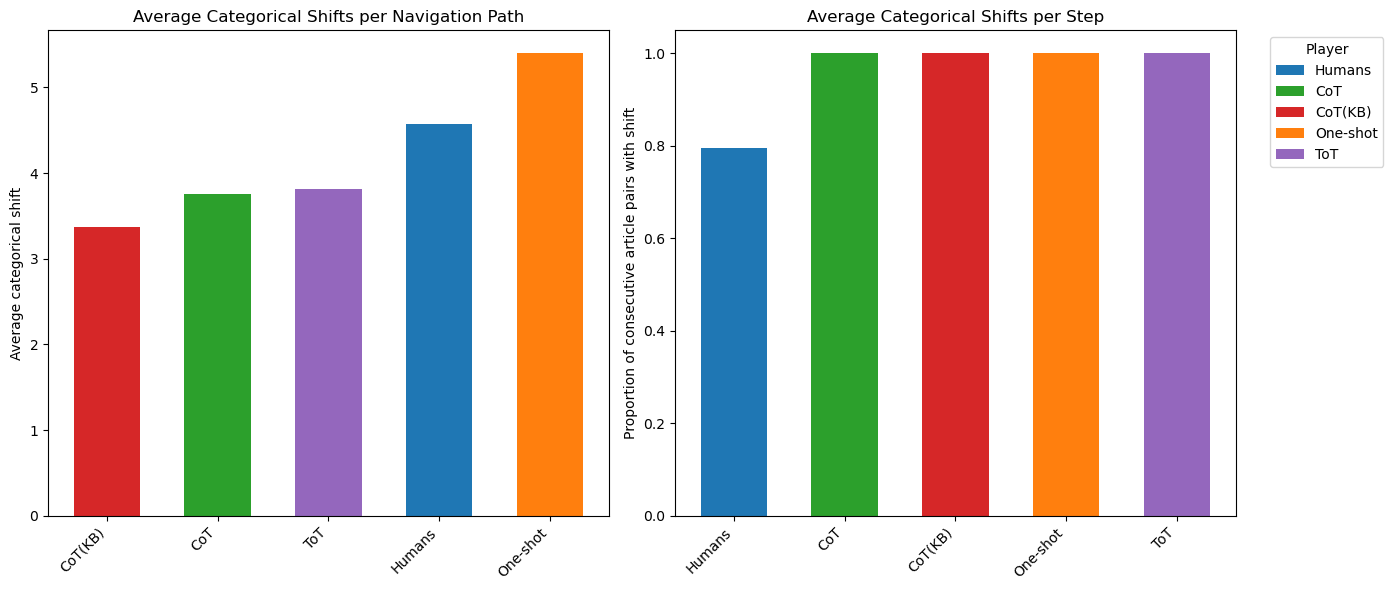

In [12]:
# Labels
labels = ["Humans", "One-shot", "CoT", "CoT(KB)", "ToT"]

# Visualize comparison
visualizer.visualize_categorical_shifts_barchart_comparison(avg_shifts_path, avg_shifts_step, labels)

## Categorical Shifts Distributions

### Violin plot of entire distribution

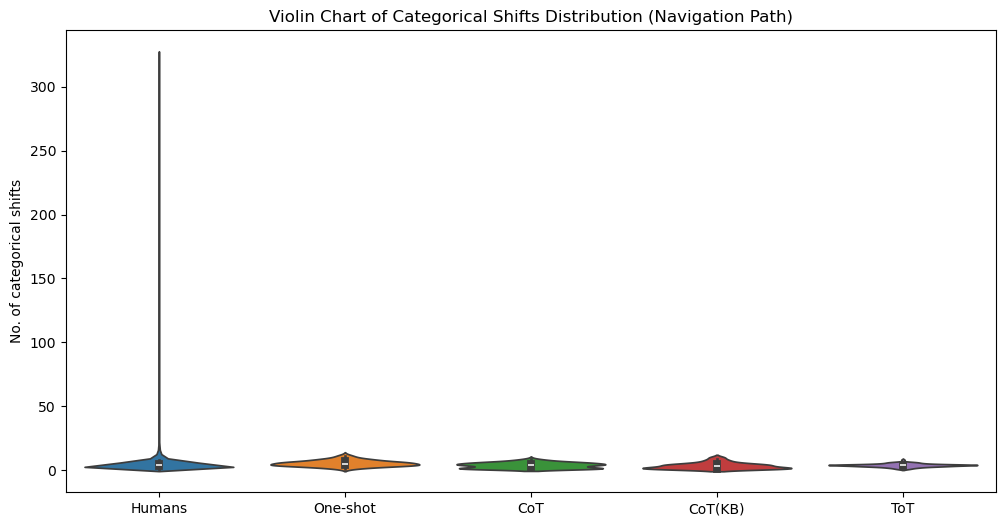

In [13]:
# Plot entire violin plots
visualizer.visualize_categorical_shifts_violin_comparison(shifts_per_path_list, labels)

### Violin plot: Zoomed in on the main distribution (i.e. ignoring extreme outliers) for better comparison

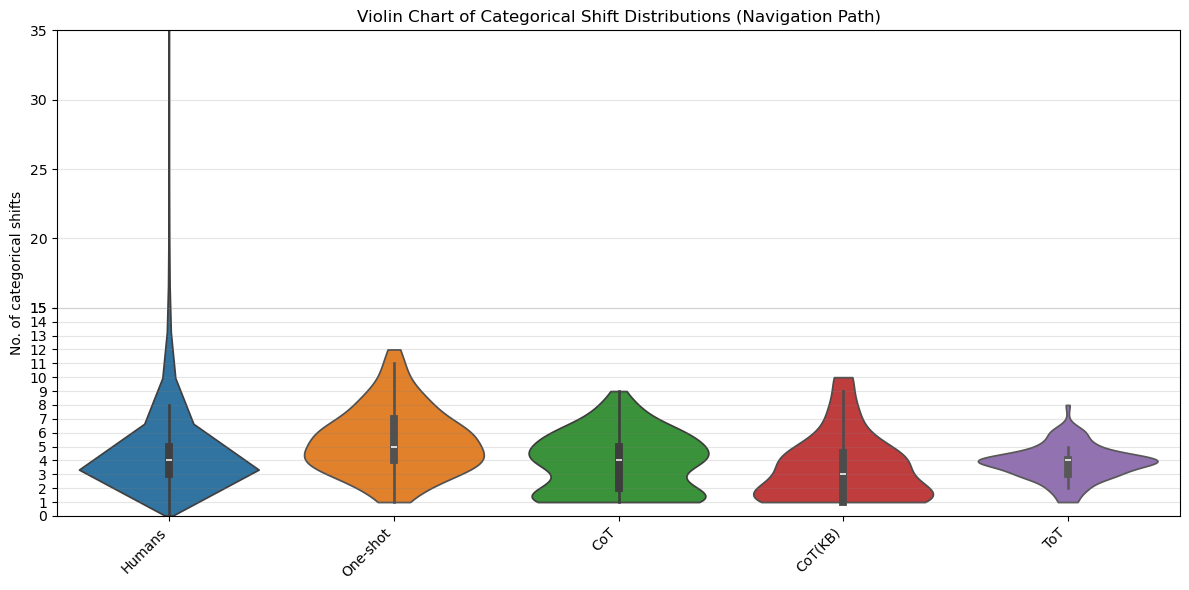

In [14]:
# Plot focused violin plots (limit outliers)
visualizer.visualize_categorical_shifts_focuses_violin_comparison(shifts_per_path_list, labels)

### Stripplots of the entire distribution

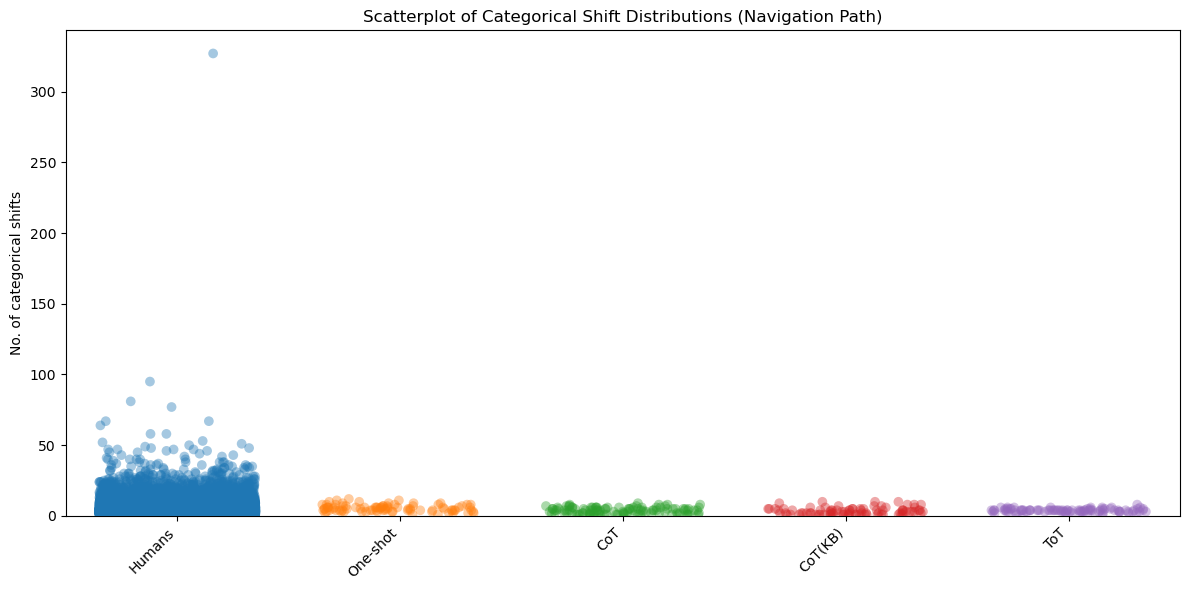

In [15]:
# Plot scatterplot of the entire distribution
visualizer.visualize_categorical_shifts_scatterplot_comparison(shifts_per_path_list, labels)

### Side-by-side stripplots

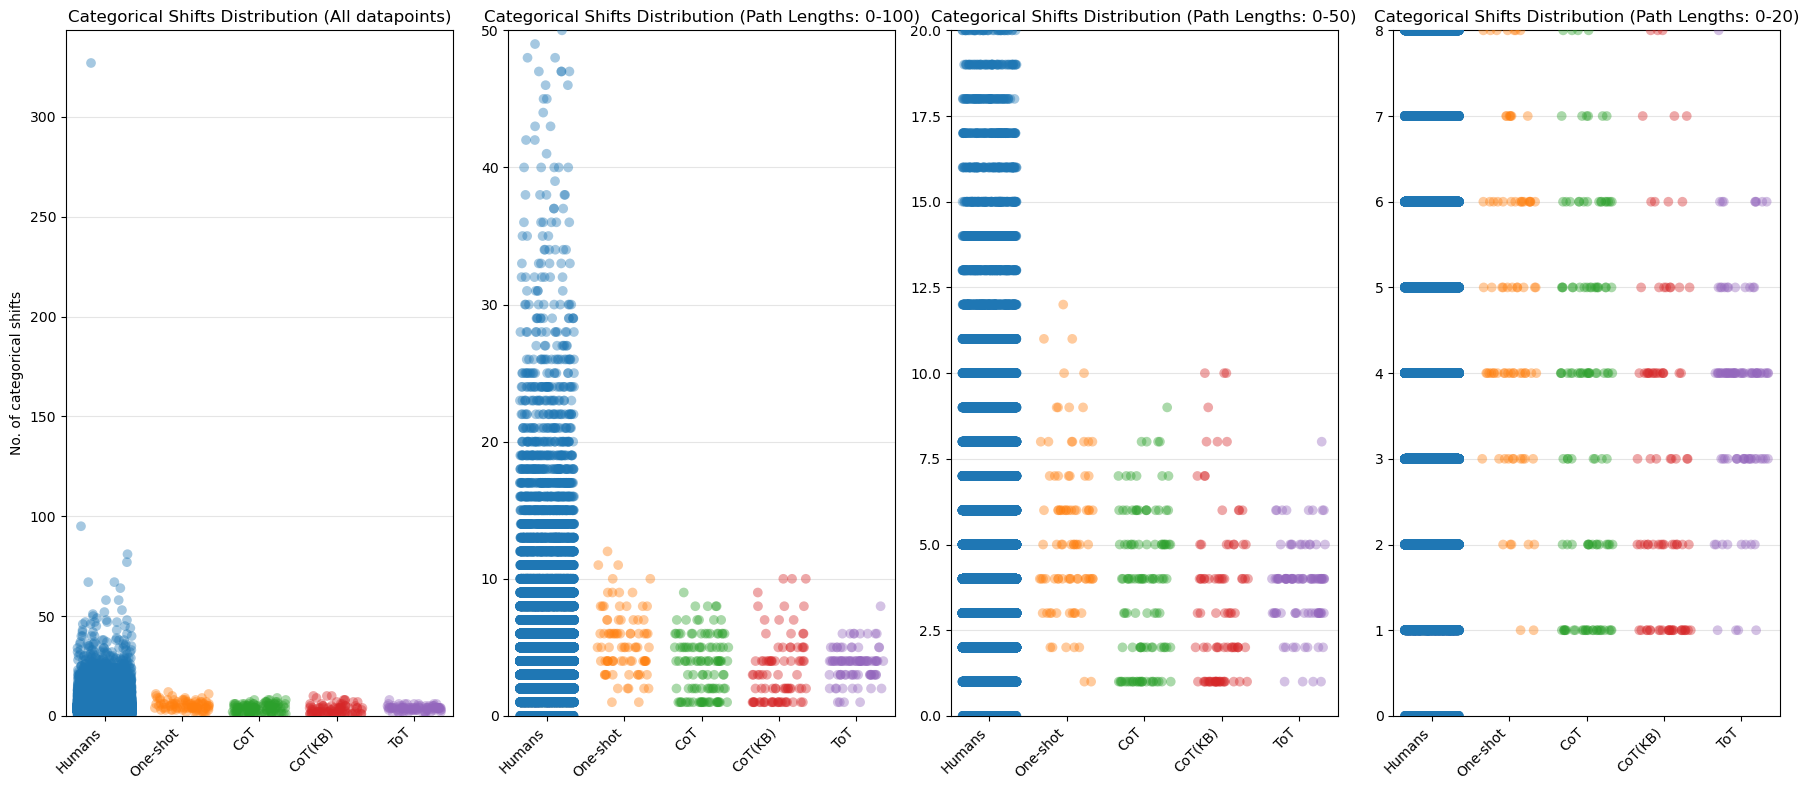

In [16]:
# Plot side-by-side scatterplot of the distribution with different focus level (i.e. max no. of categorical shifts)
visualizer.visualize_categorical_shifts_scatterplot_sidebyside_comparison(shifts_per_path_list, labels)